## Which circuit(s) are the most difficult to finish?

To measure difficulty, we will take a track's average lap time and scale that by the track length to account for different circuit lengths which is the average speed on the track. We are looking at the average driver speed on these courses based on the rationale that a circuit that has a higher number of turns or more difficult sections would make a driver slow down, increasing the amount of time needed to complete the track. Therefore, a track that would be more difficult would have a lower average speed.
<br>
We will also be looking at races from 2014 - 2016. This is to account for improvements in racing technology -- for example, race cars in 2008 would differ from cars in 2015 which would make lap times drastically different -- and different lap lengths. 2014–2016 is an ideal window for analyzing trends because car architecture, engine philosophy, and tire characteristics remained consistent without the confounding effects of major regulation resets.
<br>



##### Import packages

In [71]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

##### Read in csv files

In [72]:
races = pd.read_csv('1-Formula_One/races.csv')
circuits = pd.read_csv('1-Formula_One/circuits.csv')
df_time = pd.read_csv('1-Formula_One/lap_times.csv')
df_length = pd.read_csv('1-Formula_One/circuit_length.csv')

### Getting track lengths

Since the F1 datasets don't include any data on track length, we will need to append the track length data ourselves.
<br>
First, we will filter for races from 2014 to 2016 for our analysis. Then we will use the `raceId` column to filter for those races from our time dataframe. After filtering the 2014 - 2016 time dataframe, we will map the `circuitID` column to the time dataframe to get the circuit IDs. 

In [73]:
races_1416 = races.query('2014 <= year <= 2016')

In [74]:
# get race IDs from 2014 - 2016 and search time df for those
unique_raceID = races_1416['raceId'].unique()

df_time1416 = df_time.query('raceId in @unique_raceID')

# map circuit to race
race_lookup = races.set_index('raceId')['circuitId']
df_time1416['circuitId'] = df_time1416['raceId'].map(race_lookup)

display(df_time1416)


C:\Users\aliso\AppData\Local\Temp\ipykernel_22052\1733336176.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time1416['circuitId'] = df_time1416['raceId'].map(race_lookup)


,raceId,driverId,lap,position,time,milliseconds,circuitId
72130,900,3,1,1,1:42.038,102038,1
72131,900,3,2,1,1:37.687,97687,1
72132,900,3,3,1,1:35.765,95765,1
72133,900,3,4,1,1:34.939,94939,1
72134,900,3,5,1,1:35.438,95438,1
...,...,...,...,...,...,...,...
406321,968,825,1,22,2:05.231,125231,24
406322,968,825,2,22,2:13.467,133467,24
406323,968,825,3,22,1:48.744,108744,24
406324,968,825,4,22,1:48.601,108601,24


Next, we will create a dataframe of average values. This will contain the average track length in kilometers and the average lap time per circuit in milliseconds. In addition, the standard error will also be calculated for data visualization purposes
<br>
To get the standard error, $\mathrm{SE}=\frac{\textrm{standard deviation}}{\sqrt{n}}$, we first need to find $n$ (the sample size per circuit). This is done by grouping `df_time1416` by `circuitId` and using `.size()`.
<br>
Then we compute the mean, standard deviation, and counts of `milliseconds` with `.agg()` and sort the values by circuit ID. The standard deviation column is then used to create a standard error column by dividing `std_ms` by the counts column. The same process was repeated for `df_length`.
<br>
Finally, an overall statistics dataframe was created by merging `df_average` and `df_length_avg` into a new dataframe called `df_avg` with the counts columns dropped. This will be used to calculate values for our analysis.

In [77]:
# get mean and standard deviation lap time in milliseconds per circuit
df_average = (df_time1416.groupby('circuitId').
agg(avg_ms = ('milliseconds','mean'),
    std_ms = ('milliseconds','std'),
    n_lap_time =('milliseconds', 'count')).
sort_values(by='circuitId',ascending=True))
# use standard deviation to calculate standard error for visualization
df_average['se_ms'] = df_average['std_ms'] / np.sqrt(df_average['n_lap_time'])


#get average track length from 2014-2016 per circuit
df_length_avg = (df_length.groupby('circuitId').
                 agg(avg_km = ('circuit_length','mean'),
                     std_km = ('circuit_length','std'),
                     n_circuit = ('circuit_length','count')).
                 sort_values(by='circuitId',ascending=True))
# use standard deviation to calculate standard error for visualization
df_length_avg['se_km'] = df_length_avg['std_km'] / np.sqrt(df_length_avg['n_circuit'])

# merge the average dfs together
df_avg = pd.merge(df_average, df_length_avg, on='circuitId', how='left')
df_avg.drop(['n_lap_time','n_circuit'],axis=1,inplace=True)

display(df_avg)



,avg_ms,std_ms,se_ms,avg_km,std_km,se_km
circuitId,,,,,,
1,105309.806899,92513.159143,1791.397664,5.303000,0.000000,0.000000
2,108792.127279,10179.344381,187.036893,5.543000,0.000000,0.000000
3,102922.829292,8173.963890,146.010208,5.412000,0.000000,0.000000
4,94071.382069,5925.628847,95.661800,4.655000,0.000000,0.000000
6,88766.598623,14654.337580,229.817187,3.338000,0.001732,0.001000
7,81948.840299,8727.240477,140.179678,4.361000,0.000000,0.000000
9,135649.708924,313256.069119,6130.502276,5.891000,0.000000,0.000000
10,84115.034850,5770.523961,110.522913,4.574000,0.000000,0.000000
11,93015.229970,11364.208345,178.703729,4.381000,0.000000,0.000000


To make our final dataframe, we will add the circuit names to `df_avg` by merging with `df_length` on `circuitId`. 
<br>
(Note: `df_length` doesn't have to be filtered for years because it was already made from the 2014- 2016 dataframe; see Supplement for more on its creation). 
<br>Since we already have the circuit lengths, we will only select for `circuitId` and `circuit_name` and drop duplicate values because we already averaged the circuit lengths in `df_avg`. Now, `df_length` and `df_avg` have the same number of rows and can be merged together into `df_final`. Columns in `df_final` were rearranged to make our final calculations more visually appealing. The standard deviation columns were also removed since they weren't going to be part of the final analysis. Finally, we can find the hardest tracks in Formula 1.

In [78]:
#merge track length and average lap time
df_length = df_length[['circuitId','circuit_name']].drop_duplicates()
df_final = pd.merge(df_avg,df_length,
                     on='circuitId',
                     how='left')

# rearrange columns and rename to make the dataframe look nicer
df_final = df_final[['circuitId','circuit_name','avg_ms','se_ms','avg_km','se_km']]
display(df_final)

,circuitId,circuit_name,avg_ms,se_ms,avg_km,se_km
0,1,Albert Park Grand Prix Circuit,105309.806899,1791.397664,5.303000,0.000000
1,2,Sepang International Circuit,108792.127279,187.036893,5.543000,0.000000
2,3,Bahrain International Circuit,102922.829292,146.010208,5.412000,0.000000
3,4,Circuit de Barcelona-Catalunya,94071.382069,95.661800,4.655000,0.000000
4,6,Circuit de Monaco,88766.598623,229.817187,3.338000,0.001000
5,7,Circuit Gilles Villeneuve,81948.840299,140.179678,4.361000,0.000000
6,9,Silverstone Circuit,135649.708924,6130.502276,5.891000,0.000000
7,10,Hockenheimring,84115.034850,110.522913,4.574000,0.000000
8,11,Hungaroring,93015.229970,178.703729,4.381000,0.000000
9,13,Circuit de Spa-Francorchamps,126613.017447,1813.650033,7.004000,0.000000


### Determining the most difficult tracks

As stated in the introduction, we will determine the most difficult tracks by finding the average lap speed for each circuit. We create new average and standard error columns in `df_final` by dividing the average circuit length by the average lap time. To find the standard error of speed for data visualization the formula $SE\left(\frac{X}{Y}\right) = \sqrt{ \left( \frac{SE(X)}{Y} \right)^2 + \left( \frac{X \cdot SE(Y)}{Y^2} \right)^2}$ was used. The dataframe was then sorted by the average speed in ascending order to find the tracks with the lowest average speed.

In [79]:
# find ms/km for each track
df_final['avg_km/ms'] = df_final['avg_km']/df_final['avg_ms']
df_final['se_km/ms'] = np.sqrt(
    (df_final['se_km'] / df_final['avg_ms'])**2 +
    ((df_final['avg_km'] * df_final['se_ms']) / (df_final['avg_ms']**2))**2
)
df_final_sorted = df_final.sort_values(by='avg_km/ms',ascending=True)

display(df_final_sorted)

,circuitId,circuit_name,avg_ms,se_ms,avg_km,se_km,avg_km/ms,se_km/ms
4,6,Circuit de Monaco,88766.598623,229.817187,3.338000,0.001000,0.000038,9.800717e-08
13,18,Autódromo José Carlos Pace,103386.212208,2789.231625,4.309000,0.000000,0.000042,1.124439e-06
11,15,Marina Bay Street Circuit,119337.510664,243.614582,5.063667,0.001333,0.000042,8.733686e-08
6,9,Silverstone Circuit,135649.708924,6130.502276,5.891000,0.000000,0.000043,1.962670e-06
8,11,Hungaroring,93015.229970,178.703729,4.381000,0.000000,0.000047,9.048961e-08
17,69,Circuit of the Americas,111773.501626,256.284095,5.513000,0.000000,0.000049,1.130920e-07
3,4,Circuit de Barcelona-Catalunya,94071.382069,95.661800,4.655000,0.000000,0.000049,5.032030e-08
16,32,Autódromo Hermanos Rodríguez,86788.720438,151.133467,4.304000,0.000000,0.000050,8.635875e-08
14,22,Suzuka Circuit,116992.621700,1767.995357,5.807000,0.000000,0.000050,7.500945e-07
0,1,Albert Park Grand Prix Circuit,105309.806899,1791.397664,5.303000,0.000000,0.000050,8.565959e-07


The data was then visualized with a barplot of the top 5 most difficult tracks by average circuit speed with standard error bars.

Text(0.5, 1.0, 'Top 5 most difficult circuits by average speed')

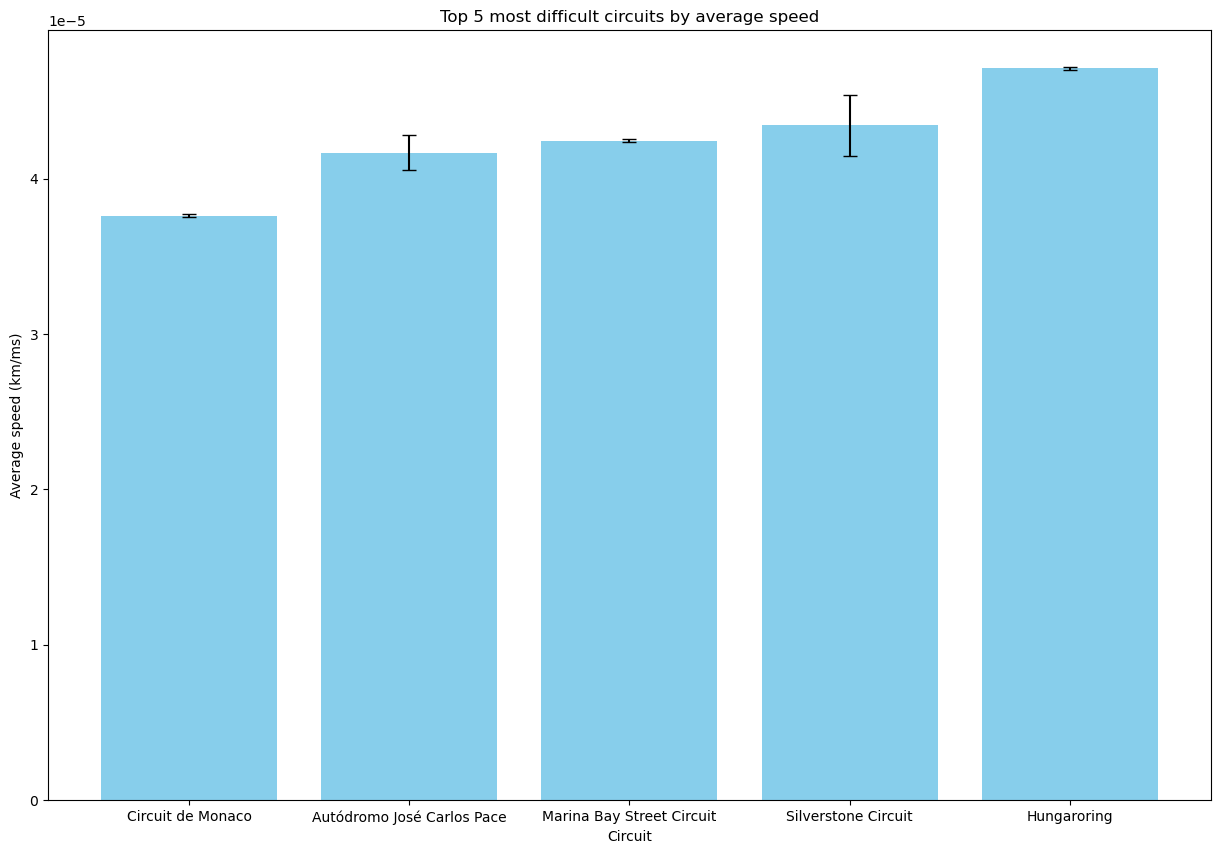

In [80]:
# plot
df_plot = df_final_sorted.head(5)

plt.figure(figsize=(15,10))
plt.bar(
    df_plot["circuit_name"],
    df_plot["avg_km/ms"],
    yerr=df_plot["se_km/ms"],  
    capsize=5,                     
    color='skyblue'
)
plt.xlabel('Circuit')
plt.ylabel('Average speed (km/ms)')
plt.title('Top 5 most difficult circuits by average speed')


(Oliver's Analysis) Maybe some of this helps?
(We can see that the Circuit de Monaco is easily the hardest course, likely because it is a well-known street circuit with short straights and tight corners. It has a reputation for being a procession and being very hard to overtake. Lewis Hamilton famously won in 2016 by doing a 47-lap stint on ultra-soft tires that weren't supposed to last more than 10 laps tops, speaking to the low speeds on this course and difficulty passing. The Marina Bay Street Circuit in Singapore is similar to Monaco, but with the caveat of always being a night race since it gets too hot to race in daylight. While there aren't as many tight turns, the faster track is pretty narrow at turn exits, leading to accidents and lost time. The Autódromo José Carlos Pace in Brazil is full of curves but has a penchant for being hit by severe rain, which in 2016 caused two red flags and many slow lap times back to the pits due to poor grip conditions that prevented tire temperature build-up on track. The Silverstone Circuit in Britain is a pretty long circuit with some slower corners even though it has three long straights for tons of overtaking. The Hungaroring has 5 hairpin turns and is significantly slower than similar length courses. There isn't really a long pit straight here to increase average speed.)

(insert summary and conclusion)

### Supplement: Creating the track length csv

To create `circuit_length.csv`, necessary columns were selected to create a new dataframe `df race circuit`that made filling in data manually easier. `raceId` and `year` were selected in the event a race in another year had a track that had different lengths compared to the other years. Then, the `name` column from `circuits.csv` was mapped to the circuit IDs in the new dataframe.

In [ ]:
df_racecircuit = races_1416[['raceId','year','circuitId','name']]

#create column of circuit name from circuit df
circuit_map = circuits.set_index("circuitId")["name"]
df_racecircuit["circuit_name"] = df_racecircuit["circuitId"].map(circuit_map)

display(df_racecircuit)

# export to fill in manually yay
df_racecircuit.to_csv('circuit_length.csv',index=False)

C:\Users\aliso\AppData\Local\Temp\ipykernel_30268\3211409759.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_racecircuit["circuit_name"] = df_racecircuit["circuitId"].map(circuit_map)


,raceId,year,circuitId,name,circuit_name
897,900,2014,1,Australian Grand Prix,Albert Park Grand Prix Circuit
898,901,2014,2,Malaysian Grand Prix,Sepang International Circuit
899,902,2014,3,Bahrain Grand Prix,Bahrain International Circuit
900,903,2014,17,Chinese Grand Prix,Shanghai International Circuit
901,904,2014,4,Spanish Grand Prix,Circuit de Barcelona-Catalunya
902,905,2014,6,Monaco Grand Prix,Circuit de Monaco
903,906,2014,7,Canadian Grand Prix,Circuit Gilles Villeneuve
904,907,2014,70,Austrian Grand Prix,Red Bull Ring
905,908,2014,9,British Grand Prix,Silverstone Circuit
906,909,2014,10,German Grand Prix,Hockenheimring


After exporting the empty csv, circuit lengths in km were added in manually in Excel. Track data came from the Wikipedia articles linked in `circuits.csv`. The dataframe was then re-imported back in as `circuit_length.csv`